# PCA on Iris Dataset

This notebook applies Principal Component Analysis (PCA) to the Iris dataset and visualizes the 2-component projection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style('whitegrid')

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

print('Feature preview:')
print(X.head())
print('')
print('Target distribution:')
print(pd.Series(y).map(dict(enumerate(iris.target_names))).value_counts())

Feature preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target distribution:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Data Scaling

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean after scaling (approx.):', np.round(X_scaled.mean(axis=0), 3))
print('Std after scaling:', np.round(X_scaled.std(axis=0), 3))

Mean after scaling (approx.): [-0. -0. -0. -0.]
Std after scaling: [1. 1. 1. 1.]


## PCA Transformation

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Reduced feature shape:', X_pca.shape)
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 3))
print('Total explained variance:', np.round(pca.explained_variance_ratio_.sum(), 3))

Reduced feature shape: (150, 2)
Explained variance ratio: [0.73  0.229]
Total explained variance: 0.958


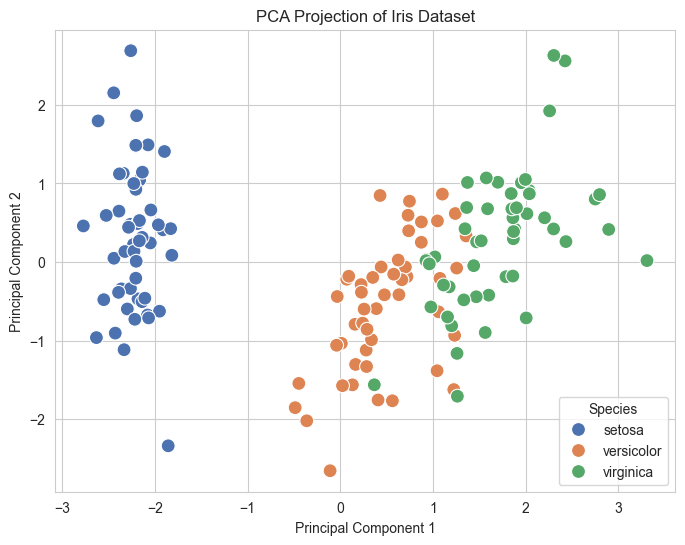

In [5]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = y.map(dict(enumerate(iris.target_names)))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='species', palette='deep', s=100)
plt.title('PCA Projection of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species')
plt.show()

## Explained Variance

In [6]:
variance_df = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': pca.explained_variance_ratio_
})
variance_df['Cumulative Variance'] = variance_df['Explained Variance Ratio'].cumsum()
variance_df

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.729624,0.729624
1,PC2,0.228508,0.958132
